In [184]:
import numpy as np
import cv2 #to work with images
from skimage.measure import label, regionprops_table #to get shape properties
import pandas as pd #make spreadsheet
from scipy import ndimage as ndi #for watershed segmentation
from skimage.feature import peak_local_max #for watershed segmentation
from skimage.segmentation import watershed #for watershed segmentation
import os
import matplotlib.pyplot as plt
from skimage.color import label2rgb

In [185]:
def get_labels(img):
    distance = ndi.distance_transform_edt(img)
    local_max_coords = peak_local_max(distance, min_distance=50)
    local_max_mask = np.zeros(distance.shape, dtype=bool)
    local_max_mask[tuple(local_max_coords.T)] = True
    markers = label(local_max_mask)
    segmented_cells = watershed(-distance, markers, mask=img)
    return segmented_cells

In [186]:
def get_axon_row(axon_df, left, right, top, bottom):
    '''
    Using the myelin bounding box find the larges axon that correspons to that myelin
    '''
    
    left = int(left)
    right = int(right)
    top = int(top)
    bottom = int(bottom)
    
    axons_id = axon_df[(((axon_df['centroid-0'])>=left) & (axon_df['centroid-0']<=right)) &
                       ((axon_df['centroid-1'])>=top) & (axon_df['centroid-1']<=bottom)]
    biggest_axon = axons_id[axons_id['area'] == axons_id['area'].max()]
    
    return biggest_axon


In [187]:
def get_morphometrics(img_path):
    '''
    Get morphometric data from a single image and return a pandas df of the morphometric data
    
    :param img_path: A path (string or object) pointing to a single segmented image in which the myelin is a middle grey and the axon is white
    
    :returns: Pandas DataFrame; morphometrics
    '''
    
    #read the image and flatten it into black and white
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    axon = cv2.inRange(img, 200, 255) #axons are everything above a medium gray
    myelin = cv2.inRange(img, 1, 255) #myelin is actually axon+myelin so everything above black
    
    #watershed labelling of axons then obtaining region properties and putting it in a DataFrame
    axon_label = get_labels(axon)
    axon_props = regionprops_table(axon_label,properties=('label', 'centroid', 'area', 'axis_minor_length', 'axis_major_length', 
                                                          'eccentricity', 'orientation', 'perimeter', 'solidity'))
    axon_df = pd.DataFrame.from_dict(axon_props)

    #watershed labelling of myelin then obtaining region properties and putting it in a DataFrame
    myelin_label = get_labels(myelin)
    myelin_props = regionprops_table(myelin_label, properties=('label', 'bbox', 'area', 'axis_minor_length', 'axis_major_length',
                                                               'perimeter'))
    myelin_df = pd.DataFrame.from_dict(myelin_props)
    
    #making an empty DataFrame to put morphometric data into
    columns = {'label':[],
               'x':[],
               'y':[],
               'axon_area':[],
               'axon_perimeter':[],
               'axon_diam':[],
               'myelin_area':[],
               'myelin_thickness':[],
               'myelin_perimeter':[],
               'eccentricity':[],
               'orientation':[],
               'solidity':[],
               'gratio':[]}
    morph_df1 = pd.DataFrame(columns)
    morph_df2 = pd.DataFrame(columns)
    
    #going through all the myelin that got accounted for in watershed
    #using myelin to compare to axons
    drop_rows = []    
    for index, row in myelin_df.iterrows():
        left = row['bbox-0']
        right = row['bbox-2']
        top = row['bbox-1']
        bottom = row['bbox-3']
        
        axon_row = get_axon_row(axon_df, left, right, top, bottom)
        if not(axon_row.empty):
            label = row['label']
            x = axon_row['centroid-0']
            y = axon_row['centroid-1']
            axon_area = axon_row['area']
            axon_perimeter = axon_row['perimeter']
            axon_diam = axon_row['axis_major_length']#(row['axis_major_length'] + row['axis_minor_length']) / 2 #getting axon diameter along the major axis
            eccentricity = axon_row['eccentricity']
            orientation = axon_row['orientation']
            solidity = axon_row['solidity']
            
            myelin_area = row['area'] - axon_area
            myelin_thickness = row['axis_major_length']
            myelin_perimeter = row['perimeter']
            gratio = axon_diam / row['axis_major_length']
            
            # if gratio.iloc[0] < 1:
                #make a one row DataFrame with axon and myelin data
            new_dict = {'label':label,
                    'x':x,
                    'y':y,
                    'axon_area':axon_area,
                    'axon_perimeter':axon_perimeter,
                    'axon_diam':axon_diam,
                    'myelin_area':myelin_area,
                    'myelin_thickness':myelin_thickness,
                    'myelin_perimeter':myelin_perimeter,
                    'eccentricity':eccentricity,
                    'orientation':orientation,
                    'solidity':solidity,
                    'gratio':gratio}

            new_df = pd.DataFrame(new_dict)
            
            #add the new data to the morphometrics DataFrame
            morph_df2 = pd.concat([morph_df2,new_df], ignore_index=True)
        
    morph_df2 = morph_df2.drop(drop_rows)
    return axon_label, myelin_label, morph_df2

In [188]:
axons, myelin, df = get_morphometrics(r"T:\Orthopaedics\Lab Imaging Data\plamothe\Colorado study PL redo\2501\RMNDist\40X_Segmented\P2501_RMNDist_40X_006.tif")

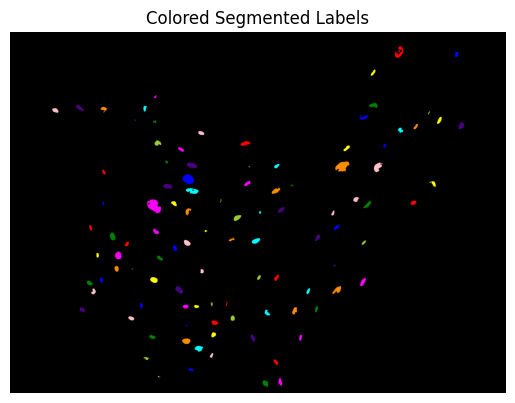

In [189]:
# Convert labels to RGB image with unique colors
colored_labels = label2rgb(myelin, bg_label=0)

# Display
plt.imshow(colored_labels)
plt.title("Colored Segmented Labels")
plt.axis('off')
plt.show()

In [190]:
df

,label,x,y,axon_area,axon_perimeter,axon_diam,myelin_area,myelin_thickness,myelin_perimeter,eccentricity,orientation,solidity,gratio
0,1.0,118.349068,2208.554037,805.0,219.379726,69.415037,777.0,76.994977,313.527958,0.885998,-0.499600,0.561367,0.901553
1,2.0,124.198502,2535.468165,267.0,72.041631,28.113361,204.0,31.380005,88.284271,0.876705,-0.063383,0.850318,0.895900
2,3.0,231.379121,2062.049451,182.0,72.669048,34.810574,280.0,42.544228,95.396970,0.979719,-0.637359,0.870813,0.818221
3,4.0,367.888889,822.777778,36.0,26.142136,9.309493,117.0,18.975233,58.491378,0.702458,1.400061,0.734694,0.490613
4,5.0,416.081784,2064.247212,538.0,109.840620,44.335272,382.0,50.770160,133.396970,0.910157,-1.536141,0.826421,0.873255
...,...,...,...,...,...,...,...,...,...,...,...,...,...
90,100.0,1851.792553,774.324468,188.0,61.183766,19.609463,117.0,28.800285,92.805087,0.748649,1.077881,0.866359,0.680877
91,101.0,1872.638393,1509.366071,224.0,64.183766,28.487144,281.0,36.135970,89.497475,0.934176,0.653789,0.921811,0.788332
92,102.0,1914.459627,1026.459627,161.0,50.384776,20.820907,170.0,28.102993,69.455844,0.874031,1.400055,0.941520,0.740879
93,104.0,1985.820946,1534.368243,296.0,78.526912,32.769988,341.0,42.710247,106.083261,0.928924,0.189949,0.927900,0.767263


In [191]:
df['axon_diam'].mean() 

30.073612005187183